# Resonance summary -- single selected quantity

Overlays one or more datasets and plots **one** quantity versus
`f* = f_lib/f_rot`, chosen by `PLOT_QUANTITY`, and saves **only** that figure
(named after the quantity so different picks never clash).

Set these in the config cell, then run all cells:

| option | meaning |
|---|---|
| `SUMMARY_FILES` | list of dataset **folders** to overlay (each holds `KineticEnergy_summary_<region>.csv` and `VelocityFFT_summary_<region>.csv`). Comment out lines to drop datasets. |
| `REGION` | `'ROI'` / `'FULL'` -- picks the summary files and tags the output |
| `FIG_FORMAT` | `'png'` or `'pdf'` |
| `SELECT_FROT` / `SELECT_FLIB` / `SELECT_FSTAR` / `SELECT_DPHI` | keep rows matching a value, a list `[a, b]`, or a `(lo, hi)` range; `None` -> all |
| `SELECT_TOPO` | `'all'`, `'bottom only'` (bottomOnly), `'top and bottom'` (TopBottom) or `'full cylinder'` (FullCylinder / k0=0) |
| `PLOT_QUANTITY` | which quantity to plot: `'velocity_fft'` (normalised velocity FFT amplitude at `f_lib`), `'mean_Ek'`, `'std_Ek'`, or `'ke_fft'` (per-point `<FFT(Ek)>` at `2 f_lib`) |

Each dataset is drawn with its own marker/colour (legend shows `k0`, topography,
`dphi`, `f_rot`), read from each folder's `param_postProcessing.json`.

**Output** -- one figure, `<quantity>_vs_fstar_<tag>[_filtered].<fmt>`, with the
quantity named in the file. A single dataset -> written in that dataset folder
with the region tag; several datasets -> the project root with the `overlay` tag;
an active `SELECT_*`/`SELECT_TOPO` filter appends `_filtered`.

## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import piv_postprocessing_lib as ppl
from piv_postprocessing_lib import (topography_arrangement, figure_filename, libration_ke_scale,
                        read_paramPostprocessing, region_tag)

%matplotlib widget


## 2. Functions

Every helper used below is defined in the single cell that follows -- grouped by role (I/O, dataset metadata, run selection, drawing). Nothing here runs the analysis; edit a helper and re-run just this cell.

In [2]:
# ---- I/O ------------------------------------------------------------------
def load_summary(path):
    """Read the summary table from .xlsx or .csv into a DataFrame."""
    ext = os.path.splitext(path)[1].lower()
    if ext in (".xlsx", ".xls"):
        return pd.read_excel(path)
    if ext == ".csv":
        return pd.read_csv(path)
    raise ValueError("Unsupported summary format: %s" % ext)


# ---- Dataset helpers (legend label, k0, topography) -----------------------

def _short_label(dsdir):
    """Compact legend name '<dataset> [<region>]' from a dataset folder."""
    return "%s [%s]" % (os.path.basename(dsdir.rstrip("/")), tag)


def _dataset_k0(dsdir):
    """k0 for a dataset folder, read from its param_postProcessing.json
    (falls back to the library default if the folder has no param file)."""
    pf = os.path.join(dsdir, ppl.PARAM_FILENAME)
    if os.path.isfile(pf):
        return read_paramPostprocessing(dsdir, apply=True).k0
    print("  [warn] no %s in %s -> using default k0=%g"
          % (ppl.PARAM_FILENAME, dsdir, ppl.k0))
    return ppl.k0


def _resolve_topo(dsdir, k0):
    """(top, bottom) topography for a dataset. k0 == 0 means no topography
    (a full cylinder) -> (False, False), the same as a 'FullCylinder' folder
    name; otherwise it is read from the folder name via topography_arrangement."""
    if k0 == 0:
        return (False, False)
    return topography_arrangement(dsdir)


# ---- Run-selection helpers ------------------------------------------------

def _match(series, sel, tol=1e-6):
    """Boolean mask selecting rows of `series`:
      None             -> all rows
      scalar           -> equal to that value (within tol)
      (lo, hi) tuple   -> range  lo <= value <= hi  (inclusive)
      [a, b, ...] list -> equal to any listed value
    """
    if sel is None:
        return pd.Series(True, index=series.index)
    if isinstance(sel, tuple) and len(sel) == 2:
        lo, hi = sel
        return (series >= lo - tol) & (series <= hi + tol)
    vals = sel if isinstance(sel, (list, set)) else [sel]
    mask = pd.Series(False, index=series.index)
    for v in vals:
        mask |= (series - v).abs() <= tol
    return mask


def _topo_ok(topo):
    """True if (top, bottom) matches SELECT_TOPO ('all' / 'bottom only' /
    'top and bottom' / 'full cylinder')."""
    top, bot = topo
    if _TOPO_SEL in ("all", "none", ""):
        return True
    if _TOPO_SEL in ("bottom only", "bottomonly", "bottom"):
        return (top == False) and (bot == True)
    if _TOPO_SEL in ("top and bottom", "topbottom", "top+bottom",
                     "top and bottom only"):
        return (top == True) and (bot == True)
    if _TOPO_SEL in ("full cylinder", "fullcylinder", "full", "none topo"):
        return (top == False) and (bot == False)
    raise ValueError("SELECT_TOPO must be 'all', 'bottom only', "
                     "'top and bottom' or 'full cylinder' (got %r)" % SELECT_TOPO)


# ---- Drawing helpers ------------------------------------------------------

MARKERS = ["o", "s", "^", "D", "v", "P", "*", "X", "h", "<"]


def draw_summary(axes, summaries, normalize=True):
    """Draw mean(Ek) and std(Ek) into the two supplied axes.

    x-axis is f* = f_lib/f_rot when normalize=True, else f_lib (Hz).

    Returns True if anything was plotted. One curve per (f_rot, dphi) sweep,
    labelled by k0 (from the file's param), dphi and f_rot. normalize=True uses
    the mean_Ekin_star / std_Ekin_star columns (Ek / E_lib); False the raw ones.
    The figure itself is created by the caller so the %matplotlib widget backend
    displays it interactively.
    """
    if normalize:
        xcol = "fstar"
        xlabel = r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$"
        panels = [("mean_Ekin_star", r"$\langle E_k \rangle / E_{\mathrm{lib}}$",
                   "Mean kinetic energy (normalized)"),
                  ("std_Ekin_star", r"std $E_k$ / $E_{\mathrm{lib}}$",
                   "Std of kinetic energy (normalized)")]
    else:
        xcol = "flib_Hz"
        xlabel = r"$f_{\mathrm{lib}}$  (Hz)"
        panels = [("mean_Ekin", r"$\langle E_k \rangle$  (m$^2$/s$^2$)",
                   "Mean kinetic energy"),
                  ("std_Ekin", r"std $E_k$  (m$^2$/s$^2$)",
                   "Std of kinetic energy")]

    any_drawn = False
    for ax, (col, ylabel, title) in zip(axes, panels):
        j = 0
        for s in summaries:
            if col not in s["df"].columns:
                continue
            dfv = s["df"].dropna(subset=[xcol, col])
            if dfv.empty:
                continue
            for (frot, dphi), gp in dfv.groupby(["frot_Hz", "dphi_deg"]):
                gp = gp.sort_values(xcol)
                ax.plot(gp[xcol], gp[col], "-" + MARKERS[j % len(MARKERS)],
                        color="C%d" % (j % 10), ms=6,
                        label=(r"$k_0$=%g (top=%s, bot=%s), "
                               r"$\delta\varphi$=%g$^\circ$, $f_{\mathrm{rot}}$=%g Hz"
                               % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot)))
                j += 1
            any_drawn = True
        ax.set_yscale("log")
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_title(title, fontsize=14)
        ax.grid(True, which="both", alpha=0.3)
        if j > 0:
            ax.legend(fontsize=8, loc="center left",
                      bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    return any_drawn


# (key, raw column, normalized column, math label) for the peak amplitudes
# recorded in the VelocityFFT summary.
AMP_QUANTITIES = [
    ("flib", "amp_flib", "amp_flib_star", r"$f_{\mathrm{lib}}$"),
    ("2flib", "amp_2flib", "amp_2flib_star", r"$2f_{\mathrm{lib}}$"),
    ("flow", "amp_flow", "amp_flow_star", r"$f_{\mathrm{low}}$"),
    ("flib_minus_flow", "amp_flib_minus_flow", "amp_flib_minus_flow_star",
     r"$f_{\mathrm{lib}}-f_{\mathrm{low}}$"),
    ("flib_plus_flow", "amp_flib_plus_flow", "amp_flib_plus_flow_star",
     r"$f_{\mathrm{lib}}+f_{\mathrm{low}}$"),
]
_AMPQ = {q[0]: q for q in AMP_QUANTITIES}


def draw_amp_summary(axes, vsummaries, quantities,
                     ylab_star=r"amplitude $/\,U_0$",
                     ylab_raw=r"amplitude  (m/s)", nan_as_floor=False,
                     panels=("star", "raw"), logy=True):
    """Peak amplitude vs f_lib into axes = [normalized_ax, raw_ax].

    quantities: keys into AMP_QUANTITIES. One curve per (summary file, f_rot,
    dphi) sweep and per quantity. With a single quantity the colour encodes the
    sweep; with several, the colour encodes the quantity and the marker the
    sweep. Returns True if anything was drawn.
    """
    multi = len(quantities) > 1
    drew = False
    _axes = np.atleast_1d(axes).ravel()
    _specs = [(a, s) for a, s in (("star", True), ("raw", False)) if a in panels]
    for ax, (_pname, star) in zip(_axes, _specs):
        xcol = "fstar" if star else "flib_Hz"
        xlabel = (r"$f_{\mathrm{lib}} / f_{\mathrm{rot}}$" if star
                  else r"$f_{\mathrm{lib}}$  (Hz)")
        gi = 0
        finite_y = []          # every finite amplitude drawn on this axis
        nan_pts = []           # (x, color, label) for NaN amplitudes -> floor
        for s in vsummaries:
            for (frot, dphi), gp in s["df"].groupby(["frot_Hz", "dphi_deg"]):
                gp = gp.sort_values(xcol)
                marker = MARKERS[gi % len(MARKERS)]
                for qi, qk in enumerate(quantities):
                    _, raw_c, star_c, qlab = _AMPQ[qk]
                    col = star_c if star else raw_c
                    if col not in gp.columns:
                        continue
                    color = "C%d" % ((qi if multi else gi) % 10)
                    if multi:
                        lab = (r"%s  ($k_0$=%g, $\delta\varphi$=%g$^\circ$)"
                               % (qlab, s["k0"], dphi))
                    else:
                        lab = (r"$k_0$=%g (top=%s, bot=%s), $\delta\varphi$=%g$^\circ$, "
                               r"$f_{\mathrm{rot}}$=%g Hz"
                               % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot))
                    g2 = gp.dropna(subset=[xcol, col])
                    _lab_used = False
                    if not g2.empty:
                        # markers only (no connecting line) in nan_as_floor mode,
                        # so gaps at NaN points are not bridged by a line.
                        fmt = marker if nan_as_floor else "-" + marker
                        ax.plot(g2[xcol], g2[col], fmt, color=color, ms=6,
                                label=lab)
                        finite_y.extend(g2[col].tolist())
                        drew = True
                        _lab_used = True
                    if nan_as_floor:
                        gn = gp[gp[xcol].notna() & gp[col].isna()]
                        for _x in gn[xcol].tolist():
                            nan_pts.append((_x, color, None if _lab_used else lab))
                            _lab_used = True   # label an all-NaN sweep only once
                            drew = True
                gi += 1
        if logy:
            ax.set_yscale("log")
        # NaN amplitudes (e.g. an insignificant f_low peak) are drawn as open
        # squares at the y-axis floor so they stay visible: the decade below the
        # smallest finite value on a log axis, or y = 0 on a linear one.
        if nan_as_floor and nan_pts:
            if logy:
                _yf = (10.0 ** np.floor(np.log10(min(finite_y)))
                       if finite_y else 1e-6)
            else:
                _yf = 0.0
            for _x, _c, _lab in nan_pts:
                ax.plot(_x, _yf, "s", color=_c, ms=8, mfc="none", mew=1.4,
                        zorder=4, clip_on=False, label=_lab)
            ax.set_ylim(bottom=_yf)
        ax.set_xlabel(xlabel, fontsize=13)
        ax.set_ylabel(ylab_star if star else ylab_raw, fontsize=13)
        ax.set_title("normalized" if star else "raw", fontsize=14)
        ax.grid(True, which="both", alpha=0.3)
        if ax.has_data():
            ax.legend(fontsize=8, loc="center left",
                      bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    return drew


def draw_flow_freq_summary(ax, vsummaries):
    """f_low/f_rot vs f* = f_lib/f_rot, one marker per (file, f_rot, dphi) sweep.

    Uses the SAME per-sweep colour/marker scheme as
    draw_amp_summary(..., ["flow"]): markers only (no connecting line); runs
    whose f_low is NaN (no significant low-frequency peak) are drawn as open
    squares at the y-axis floor so they stay visible.
    """
    xcol, ycol = "fstar", "f_low_star"
    gi = 0
    finite_y = []          # every finite f_low/f_rot drawn on the axis
    nan_pts = []           # (x, colour, label) for NaN f_low -> floor
    for s in vsummaries:
        for (frot, dphi), gp in s["df"].groupby(["frot_Hz", "dphi_deg"]):
            gp = gp.sort_values(xcol)
            marker = MARKERS[gi % len(MARKERS)]
            color = "C%d" % (gi % 10)
            lab = (r"$k_0$=%g (top=%s, bot=%s), $\delta\varphi$=%g$^\circ$, "
                   r"$f_{\mathrm{rot}}$=%g Hz"
                   % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot))
            if ycol not in gp.columns:
                gi += 1
                continue
            g2 = gp.dropna(subset=[xcol, ycol])
            _lab_used = False
            if not g2.empty:
                ax.plot(g2[xcol], g2[ycol], marker, color=color, ms=6, label=lab)
                finite_y.extend(g2[ycol].tolist())
                _lab_used = True
            gn = gp[gp[xcol].notna() & gp[ycol].isna()]
            for _x in gn[xcol].tolist():
                nan_pts.append((_x, color, None if _lab_used else lab))
                _lab_used = True
            gi += 1
    # Linear y-axis (frequency ratio). NaN f_low -> open squares at y = 0.
    if nan_pts:
        for _x, _c, _lab in nan_pts:
            ax.plot(_x, 0.0, "s", color=_c, ms=8, mfc="none", mew=1.4,
                    zorder=4, clip_on=False, label=_lab)
        ax.set_ylim(bottom=0.0)
    ax.set_xlabel(r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$", fontsize=13)
    ax.set_ylabel(r"$f_{\mathrm{low}} / f_{\mathrm{rot}}$", fontsize=13)
    ax.set_title(r"$f_{\mathrm{low}}/f_{\mathrm{rot}}$ vs $f^*$", fontsize=14)
    _drew = ax.has_data()
    if _drew:
        # Reference line f/f_rot = f*/2  (i.e. f_low = f_lib/2, the search-band edge).
        _xl = ax.get_xlim()
        _xs = np.array(_xl, dtype=float)
        ax.plot(_xs, 0.5 * _xs, "k--", lw=1, alpha=0.7, zorder=2,
                label=r"$f/f_{\mathrm{rot}} = f^*/2$")
        ax.set_xlim(_xl)
    ax.grid(True, which="both", alpha=0.3)
    if _drew:
        ax.legend(fontsize=8, loc="center left",
                      bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    return _drew


def draw_quantity_overlay(ax, summaries, col, ylabel, xcol="fstar"):
    """One quantity `col` vs f* (= f_lib/f_rot), overlaid across datasets.

    Colour encodes the (file, f_rot, dphi) sweep. Run idx 1 is a connected curve
    with filled circles; each higher run idx (2, 3, ... -- repeats of an
    identical run) is drawn as **scattered open markers with no line** (diamond
    for 2, square for 3, ...), in the sweep's colour. The legend keeps both the
    run information and the run idx. Returns True if drawn.
    """
    idx_markers = {1: "o", 2: "D", 3: "s", 4: "^", 5: "v", 6: "P", 7: "*"}
    _mk = lambda ix: (idx_markers.get(int(ix), "X") if np.isfinite(ix) else "o")
    gi = 0
    drew = False
    for s in summaries:
        df = s["df"]
        for (frot, dphi), gp in df.groupby(["frot_Hz", "dphi_deg"]):
            color = "C%d" % (gi % 10)
            gi += 1
            if col not in df.columns:
                continue
            g0 = gp.dropna(subset=[xcol, col])
            if g0.empty:
                continue
            _ix = (g0["run idx"] if "run idx" in g0.columns
                   else pd.Series(1, index=g0.index)).fillna(1)
            for _v, _sub in g0.groupby(_ix):
                _sub = _sub.sort_values(xcol)
                _lab = (r"$k_0$=%g (top=%s, bot=%s), "
                        r"$\delta\varphi$=%g$^\circ$, $f_{\mathrm{rot}}$=%g Hz"
                        r", run idx %d"
                        % (s["k0"], s["topo"][0], s["topo"][1], dphi, frot, int(_v)))
                if int(_v) <= 1:
                    # run idx 1: connected curve, filled markers.
                    ax.plot(_sub[xcol], _sub[col], "-" + _mk(_v), color=color,
                            mfc=color, ms=6, label=_lab)
                else:
                    # run idx > 1: scattered open markers, no connecting line.
                    ax.plot(_sub[xcol], _sub[col], _mk(_v), color=color,
                            mfc="none", mec=color, mew=1.3, ms=7,
                            linestyle="None", label=_lab)
            drew = True
    ax.set_yscale("log")
    ax.set_xlabel(r"$f^* = f_{\mathrm{lib}} / f_{\mathrm{rot}}$", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(True, which="both", alpha=0.3)
    if drew:
        ax.legend(fontsize=8, loc="center left",
                      bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    return drew


## 3. Configuration

Choose the datasets, region, `SELECT_*` filters and `PLOT_QUANTITY` here, then run the cells below from top to bottom.

In [3]:
# --- Mute switch -----------------------------------------------------------
# MUTE_PRINT = True silences ALL print() output (this notebook AND the library),
# so a running batch stays quiet while you edit other files. Re-run this cell to
# toggle. (Figures are unaffected.)
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print
MUTE_PRINT = False
builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# Region tag used to build the default file list and the output name.
REGION = 'ROI'


# Saved-figure format: 'png' or 'pdf'. Raw + '_normalized' versions are written.
FIG_FORMAT = 'png'

tag = region_tag(REGION)

# Dataset FOLDERS to OVERLAY on one figure -- one marker/colour per dataset. Each
# folder must hold KineticEnergy_summary_<region>.csv (and, for the velocity
# figures, VelocityFFT_summary_<region>.csv). Both summaries are loaded, so any
# PLOT_QUANTITY works; k0 / topography come from each folder's
# param_postProcessing.json and are shown in the legend.
_CEG = ("/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/"
        "TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA")
SUMMARY_FILES = [
    os.path.join(_CEG, "k6_TopBottom"),
    os.path.join(_CEG, "k20_bottomOnly"),
    os.path.join(_CEG, "k6_bottomOnly"),
    os.path.join(_CEG, "k6_TopBottom_notAligned"),
    os.path.join(_CEG, "FullCylinder"),
]

# --- Selected-quantity figure --------------------------------------------
# The cell "Selected quantity vs f*" plots ONE quantity (overlaid across the
# summary files) and writes it with that quantity named in the file name. Pick:
#   'velocity_fft' -> normalised velocity FFT amplitude at f_lib   (amp_flib_star)
#   'mean_Ek'      -> mean kinetic energy                          (mean_Ekin_star)
#   'std_Ek'       -> std of kinetic energy                        (std_Ekin_star)
#   'ke_fft'       -> kinetic-energy FFT amplitude, per-point <FFT(Ek)>, at
#                     2*f_lib                                      (amp_2flib_star)
PLOT_QUANTITY = 'velocity_fft'  # 'mean_Ek', 'std_Ek', 'ke_fft'

# Filtering: None (all), a value, a list [0.40, 0.44], or a (lo, hi) RANGE
# tuple e.g. (0.1, 1.0) -- inclusive. (Applied in the filter cell below.)
SELECT_FROT  = 0.5     # Hz,  e.g. 0.5
SELECT_FLIB  = None    # Hz,  e.g. 0.44  or  [0.40, 0.44]
SELECT_FSTAR = (0, 1)  # e.g. 3.0  or  (0.1, 1.0) for a range
SELECT_DPHI  = (2, 4)   # deg, e.g. 2.0

# Topography selection: one of
#   'all'            -> any topography (no filter)
#   'bottom only'    -> bottomOnly datasets  (top=False, bottom=True)
#   'top and bottom' -> TopBottom datasets   (top=True,  bottom=True)
#   'full cylinder'  -> FullCylinder / k0=0  (top=False, bottom=False)
SELECT_TOPO = "all"



# Figure output stem (xaxis/normalized appended). None -> beside the 1st summary.
OUTPUT_STEM = None

# Where the overlay figures are written: with a SINGLE dataset, in that dataset
# folder; with several, gathered in the project root.
_OUT_DIR = SUMMARY_FILES[0] if len(SUMMARY_FILES) == 1 else _CEG
# Name tag on the output figures: the region tag for a SINGLE dataset (so the
# names match that dataset's own figures, e.g. KineticEnergy_vs_fstar_ROI), or
# 'overlay' when several datasets are combined.
_NAME_TAG = tag if len(SUMMARY_FILES) == 1 else 'overlay'

## 4. Load the summaries

Reads each dataset's `KineticEnergy_summary_<region>.csv` and `VelocityFFT_summary_<region>.csv` into `summaries` / `vfft_summaries`, attaching `k0` and the topography arrangement.

In [4]:
# KineticEnergy summaries (energy stats AND the Ek-FFT amplitudes -- one file).
summaries = []
for _dir in SUMMARY_FILES:
    _ke = os.path.join(_dir, "KineticEnergy_summary_%s.csv" % tag)
    if not os.path.isfile(_ke):
        print("  [skip] no %s in %s" % (os.path.basename(_ke), _dir))
        continue
    _df = load_summary(_ke)
    _k0 = _dataset_k0(_dir)
    # Fill the normalized columns if the summary predates them.
    if "mean_Ekin_star" not in _df.columns:
        _scale = libration_ke_scale(_df["dphi_deg"], _df["flib_Hz"])
        _df["mean_Ekin_star"] = _df["mean_Ekin"] / _scale
        _df["std_Ekin_star"] = _df["std_Ekin"] / _scale
    summaries.append({"name": _short_label(_dir), "df": _df, "k0": _k0,
                      "topo": _resolve_topo(_dir, _k0)})
    print("Loaded %3d runs   k0=%g   %s" % (len(_df), _k0, _ke))
print("\n%d dataset(s) loaded (KineticEnergy)." % len(summaries))

# Sibling VelocityFFT summaries (for the velocity peak-amplitude figures).
vfft_summaries = []
for _dir in SUMMARY_FILES:
    _vf = os.path.join(_dir, "VelocityFFT_summary_%s.csv" % tag)
    if not os.path.isfile(_vf):
        print("  [skip] no %s in %s" % (os.path.basename(_vf), _dir))
        continue
    _vdf = load_summary(_vf)
    _k0v = _dataset_k0(_dir)
    vfft_summaries.append({"name": _short_label(_dir), "df": _vdf,
                           "k0": _k0v,
                           "topo": _resolve_topo(_dir, _k0v)})
    print("Loaded %3d runs   VelocityFFT   %s" % (len(_vdf), _vf))
print("%d dataset(s) loaded (VelocityFFT)." % len(vfft_summaries))

# The Ek-spectrum amplitudes (amp_2flib, ...) live in the combined KineticEnergy
# summary, so the Ek-amplitude figure reuses `summaries`.
kefft_summaries = summaries


Loaded  36 runs   k0=6   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/KineticEnergy_summary_ROI.csv
Loaded  40 runs   k0=20   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k20_bottomOnly/KineticEnergy_summary_ROI.csv
Loaded  57 runs   k0=6   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_bottomOnly/KineticEnergy_summary_ROI.csv
Loaded   3 runs   k0=6   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom_notAligned/KineticEnergy_summary_ROI.csv
Loaded  34 runs   k0=0   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/FullCylinder/KineticEnergy_summary_ROI.csv

5 dataset(s) loaded (KineticEnergy).
Loaded  38 runs   VelocityFFT   /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderEx

## 5. Apply the `SELECT_*` filters

Keeps the rows matching the `SELECT_*` / `SELECT_TOPO` choices, producing `summaries_sel` / `vfft_summaries_sel` (and `kefft_summaries_sel`).

In [5]:
_TOPO_SEL = str(SELECT_TOPO).strip().lower()
no_filter = (all(s is None for s in
                 (SELECT_FROT, SELECT_FLIB, SELECT_FSTAR, SELECT_DPHI))
             and _TOPO_SEL in ("all", "none", ""))

summaries_sel = []
for s in summaries:
    if not _topo_ok(s["topo"]):
        continue
    df = s["df"]
    dfs = df[_match(df["frot_Hz"], SELECT_FROT)
             & _match(df["flib_Hz"], SELECT_FLIB)
             & _match(df["fstar"], SELECT_FSTAR)
             & _match(df["dphi_deg"], SELECT_DPHI)].copy()
    summaries_sel.append({"name": s["name"], "df": dfs, "k0": s["k0"],
                          "topo": s["topo"]})
    print("%-34s %3d of %3d runs%s"
          % (s["name"], len(dfs), len(df), "  (no filter)" if no_filter else ""))

vfft_summaries_sel = []
for s in vfft_summaries:
    if not _topo_ok(s["topo"]):
        continue
    df = s["df"]
    dfs = df[_match(df["frot_Hz"], SELECT_FROT)
             & _match(df["flib_Hz"], SELECT_FLIB)
             & _match(df["fstar"], SELECT_FSTAR)
             & _match(df["dphi_deg"], SELECT_DPHI)].copy()
    vfft_summaries_sel.append({"name": s["name"], "df": dfs, "k0": s["k0"],
                               "topo": s["topo"]})

# Ek-spectrum amplitudes come from the same combined KineticEnergy summary.
kefft_summaries_sel = summaries_sel


k6_TopBottom [ROI]                  20 of  36 runs
k20_bottomOnly [ROI]                16 of  40 runs
k6_bottomOnly [ROI]                 22 of  57 runs
k6_TopBottom_notAligned [ROI]        3 of   3 runs
FullCylinder [ROI]                  18 of  34 runs


## 6. Plot the selected quantity

Draws and saves the single `PLOT_QUANTITY` figure, overlaid across all selected datasets.

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/VelocityFFT_amp_flib_norm_vs_fstar_overlay_filtered.png


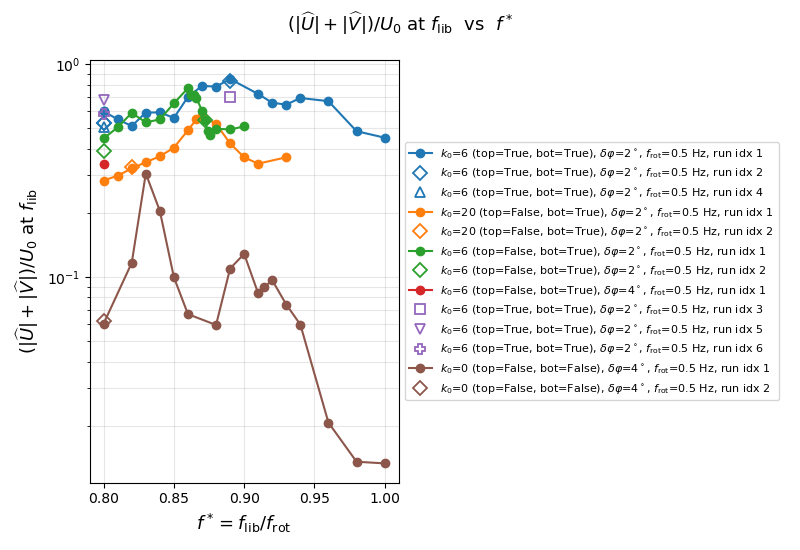

In [6]:
# Selected quantity vs f* -- controlled by PLOT_QUANTITY (config cell). The
# chosen quantity is named in the output file so different picks never clash.
_ft = "" if no_filter else "_filtered"
# (source list, column, y-label, file tag) for each choice.
_QMAP = {
    "velocity_fft": (vfft_summaries_sel, "amp_flib_star",
                     r"$(|\widehat{U}|+|\widehat{V}|)/U_0$ at $f_{\mathrm{lib}}$",
                     "VelocityFFT_amp_flib_norm"),
    "mean_Ek": (summaries_sel, "mean_Ekin_star",
                r"$\langle E_k \rangle / E_{\mathrm{lib}}$", "meanKineticEnergy"),
    "std_Ek": (summaries_sel, "std_Ekin_star",
               r"std $E_k / E_{\mathrm{lib}}$", "stdKineticEnergy"),
    "ke_fft": (summaries_sel, "amp_2flib_star",
               r"$|\langle\widehat{E_k}\rangle| / E_{\mathrm{lib}}$ at $2f_{\mathrm{lib}}$",
               "KineticEnergyFFT_amp_2flib"),
}
if PLOT_QUANTITY not in _QMAP:
    raise ValueError("PLOT_QUANTITY must be one of %s (got %r)"
                     % (list(_QMAP), PLOT_QUANTITY))
_src, _col, _ylab, _qtag = _QMAP[PLOT_QUANTITY]
if any(not s["df"].empty for s in _src):
    fig, ax = plt.subplots(figsize=(8, 5.5))
    draw_quantity_overlay(ax, _src, _col, _ylab)
    fig.suptitle(r"%s  vs  $f^*$" % _ylab, fontsize=13)
    fig.tight_layout()
    # The quantity (_qtag) is in the file name so the plot is self-identifying.
    _out = figure_filename(os.path.join(_OUT_DIR, "%s_vs_fstar_%s" % (_qtag, _NAME_TAG) + _ft),
                           FIG_FORMAT)
    fig.savefig(_out, dpi=200, bbox_inches="tight")
    print("Figure written to:\n  %s" % _out)
else:
    print("No summaries for PLOT_QUANTITY=%r -- selected-quantity figure skipped." % PLOT_QUANTITY)